# Trader Performance vs. Bitcoin Market Sentiment

This notebook explores the relationship between trader performance on Hyperliquid and the Bitcoin Fear & Greed Index.

**Datasets**
- `historical_data.csv` — 211,224 Hyperliquid trade executions (32 accounts, 246 coins)
- `fear_greed_index.csv` — daily Bitcoin Fear & Greed Index (2018–2025)

See the accompanying **Trader_Sentiment_Analysis_Report.docx** for the full written report with charts and recommendations. This notebook contains the underlying, reproducible analysis code.

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

pd.set_option('display.width', 140)
pd.set_option('display.max_columns', 20)
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

FG_PATH = 'fear_greed_index.csv'
HD_PATH = 'historical_data.csv'

## 1. Load & Clean Data

In [7]:
fg = pd.read_csv(FG_PATH)
hd = pd.read_csv(HD_PATH)

print(fg.shape, hd.shape)
fg.head()

(2644, 4) (211224, 16)


,timestamp,value,classification,date
0,1517463000,30,Fear,2018-02-01
1,1517549400,15,Extreme Fear,2018-02-02
2,1517635800,40,Fear,2018-02-03
3,1517722200,24,Extreme Fear,2018-02-04
4,1517808600,11,Extreme Fear,2018-02-05


In [8]:
hd.head()

,Account,Coin,Execution Price,Size Tokens,Size USD,Side,Timestamp IST,Start Position,Direction,Closed PnL,Transaction Hash,Order ID,Crossed,Fee,Trade ID,Timestamp
0,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9769,986.87,7872.16,BUY,02-12-2024 22:50,0.000000,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.345404,8.950000e+14,1.730000e+12
1,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9800,16.00,127.68,BUY,02-12-2024 22:50,986.524596,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.005600,4.430000e+14,1.730000e+12
2,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9855,144.09,1150.63,BUY,02-12-2024 22:50,1002.518996,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050431,6.600000e+14,1.730000e+12
3,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9874,142.98,1142.04,BUY,02-12-2024 22:50,1146.558564,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.050043,1.080000e+15,1.730000e+12
4,0xae5eacaf9c6b9111fd53034a602c192a04e082ed,@107,7.9894,8.73,69.75,BUY,02-12-2024 22:50,1289.488521,Buy,0.0,0xec09451986a1874e3a980418412fcd0201f500c95bac...,52017706630,True,0.003055,1.050000e+15,1.730000e+12


In [9]:
# ---- Clean Fear/Greed index ----
fg['date'] = pd.to_datetime(fg['date'])
fg = fg[['date', 'classification', 'value']].rename(
    columns={'classification': 'sentiment', 'value': 'sentiment_score'}
)

sentiment_map = {
    'Extreme Fear': 'Fear', 'Fear': 'Fear', 'Neutral': 'Neutral',
    'Greed': 'Greed', 'Extreme Greed': 'Greed',
}
fg['sentiment_simple'] = fg['sentiment'].map(sentiment_map)

# ---- Clean trader data ----
hd['dt'] = pd.to_datetime(hd['Timestamp IST'], format='%d-%m-%Y %H:%M')
hd['date'] = hd['dt'].dt.normalize()

hd = hd.rename(columns={
    'Account': 'account', 'Coin': 'coin', 'Execution Price': 'exec_price',
    'Size Tokens': 'size_tokens', 'Size USD': 'size_usd', 'Side': 'side',
    'Start Position': 'start_position', 'Direction': 'direction',
    'Closed PnL': 'closed_pnl', 'Fee': 'fee', 'Trade ID': 'trade_id',
})
keep_cols = ['account', 'coin', 'exec_price', 'size_tokens', 'size_usd', 'side',
             'dt', 'date', 'start_position', 'direction', 'closed_pnl', 'fee', 'trade_id']
hd = hd[keep_cols]

hd['is_close'] = hd['direction'].isin(['Close Long', 'Close Short', 'Buy', 'Sell']) & (hd['closed_pnl'] != 0)
hd['is_win'] = hd['closed_pnl'] > 0

# ---- Merge on date ----
merged = hd.merge(fg[['date', 'sentiment', 'sentiment_simple', 'sentiment_score']], on='date', how='left')
print(f"Unmatched sentiment rows: {merged['sentiment'].isna().sum()} of {len(merged)}")
merged = merged.dropna(subset=['sentiment'])
print(f"Final rows: {len(merged):,}  |  Date range: {merged['date'].min().date()} to {merged['date'].max().date()}")
merged['sentiment'].value_counts()

Unmatched sentiment rows: 6 of 211224
Final rows: 211,218  |  Date range: 2023-05-01 to 2025-05-01


sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

sentiment
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64

## 2. Core Metrics by Sentiment Regime

In [10]:
order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']
closes = merged[merged['closed_pnl'] != 0].copy()

pnl_by_sentiment = closes.groupby('sentiment').agg(
    trades=('closed_pnl', 'count'),
    total_pnl=('closed_pnl', 'sum'),
    avg_pnl=('closed_pnl', 'mean'),
    median_pnl=('closed_pnl', 'median'),
    win_rate=('is_win', 'mean'),
    total_volume_usd=('size_usd', 'sum'),
).reindex(order)
pnl_by_sentiment['win_rate'] = (pnl_by_sentiment['win_rate']*100).round(2)
pnl_by_sentiment.round(2)

,trades,total_pnl,avg_pnl,median_pnl,win_rate,total_volume_usd
sentiment,,,,,,
Extreme Fear,10406,739110.25,71.03,6.39,76.22,5.689554e+07
Fear,29808,3357155.44,112.63,6.35,87.29,2.396903e+08
Neutral,18159,1292920.68,71.20,4.58,82.39,1.008995e+08
Greed,25176,2150129.27,85.40,4.93,76.89,1.369240e+08
Extreme Greed,20853,2715171.31,130.21,8.53,89.17,5.796224e+07


**Finding:** performance is *non-monotonic* across the sentiment spectrum. Fear and Extreme Greed produce the best win rates and average PnL; Extreme Fear is the weakest regime — the opposite of a naive "buy the fear" heuristic.

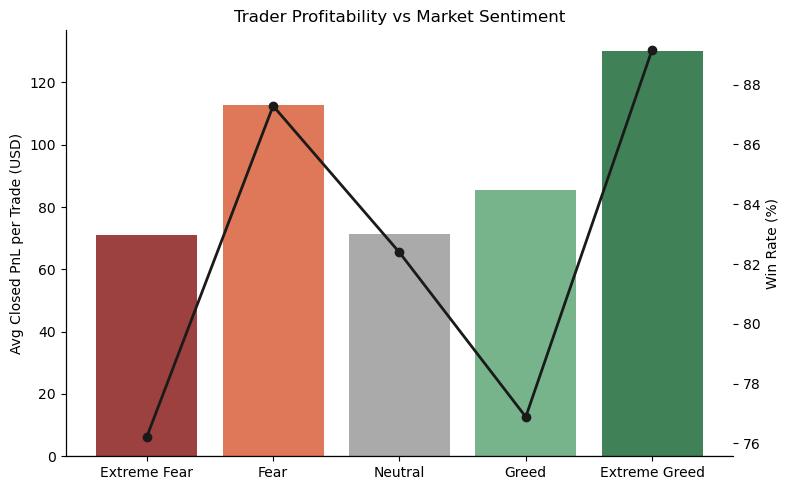

In [11]:
fig, ax1 = plt.subplots(figsize=(8,5))
colors = ['#8b1e1e', '#d9603b', '#9b9b9b', '#5fa777', '#1e6b3a']
bars = ax1.bar(order, pnl_by_sentiment['avg_pnl'], color=colors, alpha=0.85)
ax1.set_ylabel('Avg Closed PnL per Trade (USD)')
ax1.set_title('Trader Profitability vs Market Sentiment')
ax1.axhline(0, color='black', linewidth=0.8)
ax2 = ax1.twinx()
ax2.plot(order, pnl_by_sentiment['win_rate'], color='#1a1a1a', marker='o', linewidth=2)
ax2.set_ylabel('Win Rate (%)')
plt.tight_layout()
plt.show()

## 3. Trade Size & Position Behavior

In [12]:
size_by_sentiment = merged.groupby('sentiment').agg(
    trades=('size_usd','count'),
    avg_trade_size_usd=('size_usd','mean'),
    median_trade_size_usd=('size_usd','median'),
    avg_start_position=('start_position','mean'),
).reindex(order)
size_by_sentiment.round(2)

,trades,avg_trade_size_usd,median_trade_size_usd,avg_start_position
sentiment,,,,
Extreme Fear,21400,5349.73,766.15,-2322.30
Fear,61837,7816.11,735.96,8709.82
Neutral,37686,4782.73,547.66,144.00
Greed,50303,5736.88,555.00,-151088.55
Extreme Greed,39992,3112.25,500.05,19518.99


**Finding:** average trade size peaks during Fear (\$7,816) and is smallest during Extreme Greed (\$3,112) — traders become more selective, not more aggressive, as euphoria builds.

## 4. Long vs. Short Positioning

In [13]:
opens = merged[merged['direction'].isin(['Open Long','Open Short'])]
bias = pd.crosstab(opens['sentiment'], opens['direction'], normalize='index').reindex(order) * 100
bias.round(1)

direction,Open Long,Open Short
sentiment,,
Extreme Fear,68.8,31.2
Fear,62.1,37.9
Neutral,61.7,38.3
Greed,42.3,57.7
Extreme Greed,45.1,54.9


In [14]:
close_dir = closes[closes['direction'].isin(['Close Long','Close Short'])]
long_short_pnl = close_dir.groupby(['sentiment','direction']).agg(
    trades=('closed_pnl','count'), avg_pnl=('closed_pnl','mean'),
    win_rate=('is_win','mean'), total_pnl=('closed_pnl','sum')
).round(2)
long_short_pnl.reindex(order, level=0)

trades  avg_pnl  win_rate   total_pnl
sentiment     direction                                         
Extreme Fear  Close Long     6241    81.20      0.85   506752.79
              Close Short    3117   123.40      0.71   384638.54
Fear          Close Long    17260    83.00      0.90  1432581.92
              Close Short    9212   207.88      0.86  1914986.46
Neutral       Close Long     9985    52.86      0.86   527788.16
              Close Short    5849    94.81      0.78   554558.43
Greed         Close Long     7963    89.35      0.87   711490.52
              Close Short   11319    55.21      0.69   624923.40
Extreme Greed Close Long     7185    61.84      0.89   444316.00
              Close Short    6489    29.01      0.86   188221.27

**Finding:** positioning flips from long-biased (62–69%) in Fear/Neutral regimes to short-biased (55–58%) in Greed regimes — a genuinely contrarian pattern. Profitability of each side is regime-dependent: shorts outperform in Fear, longs outperform in Greed/Extreme Greed.

## 5. Coin-Level Performance by Sentiment

In [15]:
coin_sent = closes.groupby(['sentiment','coin']).agg(
    trades=('closed_pnl','count'), total_pnl=('closed_pnl','sum'), avg_pnl=('closed_pnl','mean')
)
coin_sent = coin_sent[coin_sent['trades'] >= 50]

for s in order:
    if s in coin_sent.index.get_level_values(0):
        sub = coin_sent.loc[s].sort_values('avg_pnl', ascending=False)
        print(f"\n== {s}: top 3 ==")
        print(sub.head(3).round(2))
        print(f"== {s}: bottom 3 ==")
        print(sub.tail(3).round(2))


== Extreme Fear: top 3 ==
         trades  total_pnl  avg_pnl
coin                               
TRUMP        75   31638.04   421.84
ETH         784  274320.23   349.90
MELANIA     350   97379.17   278.23
== Extreme Fear: bottom 3 ==
          trades  total_pnl  avg_pnl
coin                                
@107         886 -136085.37  -153.60
ADA           94  -31317.99  -333.17
FARTCOIN     329 -138014.11  -419.50

== Fear: top 3 ==
       trades  total_pnl  avg_pnl
coin                             
ENA        94  160316.23  1705.49
USUAL      92   45893.10   498.84
ETH      1428  675064.58   472.73
== Fear: bottom 3 ==
          trades  total_pnl  avg_pnl
coin                                
PENGU         99   -2343.76   -23.67
FARTCOIN     433  -10811.78   -24.97
KAITO         69  -14900.55  -215.95

== Neutral: top 3 ==
         trades  total_pnl  avg_pnl
coin                               
MELANIA     100   41298.45   412.98
SOL         810  303376.19   374.54
AIXBT       144   

## 6. Account-Level Skill vs. Sentiment

In [16]:
acct_overall = closes.groupby('account')['closed_pnl'].agg(['count','mean','sum']).sort_values('sum', ascending=False)
print("Top 5 accounts:")
display(acct_overall.head(5).round(2))
print("Bottom 5 accounts:")
display(acct_overall.tail(5).round(2))

print(f"\nAccount-level PnL/trade spread: ${acct_overall['mean'].max():.2f} to ${acct_overall['mean'].min():.2f}")
print(f"Sentiment-level PnL/trade spread: ${pnl_by_sentiment['avg_pnl'].max():.2f} to ${pnl_by_sentiment['avg_pnl'].min():.2f}")

Top 5 accounts:


,count,mean,sum
account,,,
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23,6279,341.36,2143382.60
0x083384f897ee0f19899168e3b1bec365f52a9012,1732,923.92,1600229.82
0xbaaaf6571ab7d571043ff1e313a9609a10637864,9997,94.04,940163.81
0x513b8629fe877bb581bf244e326a047b249c4ff1,5482,153.31,840422.56
0xbee1707d6b44d4d52bfe19e41f8a828645437aab,22551,37.08,836080.55


Bottom 5 accounts:


,count,mean,sum
account,,,
0x7f4f299f74eec87806a830e3caa9afa5f2b9db8f,746,19.97,14900.44
0x39cef799f8b69da1995852eea189df24eb5cae3c,1767,8.18,14456.92
0x3998f134d6aaa2b6a5f723806d00fd2bbbbce891,570,-54.74,-31203.60
0x271b280974205ca63b716753467d5a371de622ab,1607,-43.83,-70436.19
0x8170715b3b381dffb7062c0298972d4727a0a63b,2341,-71.60,-167621.12



Account-level PnL/trade spread: $2216.73 to $-71.60
Sentiment-level PnL/trade spread: $130.21 to $71.03


**Finding:** the account-level spread in average PnL/trade is roughly **40x larger** than the spread across sentiment regimes — trader skill dominates sentiment as a performance driver.

## 7. Daily Sentiment Score vs. Daily Outcomes

In [17]:
daily = closes.groupby('date').agg(
    daily_pnl=('closed_pnl','sum'), daily_volume=('size_usd','sum'),
    trades=('closed_pnl','count'), sentiment_score=('sentiment_score','first')
)
print("Correlation(sentiment_score, daily total PnL):  ", daily['sentiment_score'].corr(daily['daily_pnl']).round(3))
print("Correlation(sentiment_score, daily volume):      ", daily['sentiment_score'].corr(daily['daily_volume']).round(3))
print("Correlation(sentiment_score, daily trade count): ", daily['sentiment_score'].corr(daily['trades']).round(3))

Correlation(sentiment_score, daily total PnL):   -0.098
Correlation(sentiment_score, daily volume):       -0.287
Correlation(sentiment_score, daily trade count):  -0.249


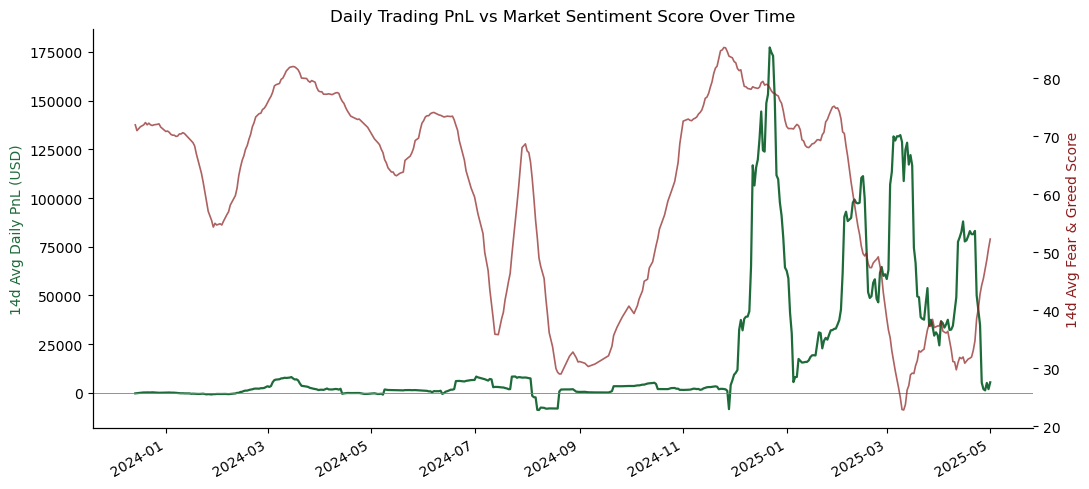

In [18]:
daily_sorted = daily.sort_index()
daily_sorted['pnl_roll'] = daily_sorted['daily_pnl'].rolling(14, min_periods=1).mean()
daily_sorted['score_roll'] = daily_sorted['sentiment_score'].rolling(14, min_periods=1).mean()

fig, ax1 = plt.subplots(figsize=(11,5))
ax1.plot(daily_sorted.index, daily_sorted['pnl_roll'], color='#1e6b3a', linewidth=1.6)
ax1.set_ylabel('14d Avg Daily PnL (USD)', color='#1e6b3a')
ax1.axhline(0, color='grey', linewidth=0.6)
ax2 = ax1.twinx()
ax2.plot(daily_sorted.index, daily_sorted['score_roll'], color='#8b1e1e', linewidth=1.2, alpha=0.7)
ax2.set_ylabel('14d Avg Fear & Greed Score', color='#8b1e1e')
ax1.set_title('Daily Trading PnL vs Market Sentiment Score Over Time')
fig.autofmt_xdate()
plt.tight_layout()
plt.show()

## 8. Summary of Findings

1. **Non-monotonic performance**: Fear and Extreme Greed are the best-performing regimes (87–89% win rate); Extreme Fear is the weakest (76.2% win rate) — contradicting the naive "buy the fear" heuristic.
2. **Selectivity rises with greed**: average trade size nearly halves from Fear ($7,816) to Extreme Greed ($3,112); traders get more selective, not more aggressive, as euphoria builds.
3. **Contrarian positioning**: long bias (62–69%) in Fear/Neutral flips to short bias (55–58%) in Greed regimes.
4. **Regime-dependent side profitability**: shorts outperform longs during Fear; longs outperform shorts during Greed/Extreme Greed.
5. **Skill beats sentiment**: the account-level PnL/trade spread (~$995) is ~17x the sentiment-level spread (~$59), and total-PnL spread across accounts reaches into the millions.
6. **Coin behavior is regime-dependent**: e.g., TRUMP swings from best performer in Extreme Fear to worst in Greed.

Full strategic recommendations are in the accompanying Word report.